In [57]:
import pandas as pd

df = pd.read_csv("data/reduced_world_real_estate_data.csv")

In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144961 entries, 0 to 144960
Data columns (total 7 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Country             144961 non-null  object 
 1   Property Type       144961 non-null  object 
 2   Value & Size        144961 non-null  float64
 3   Height              144961 non-null  float64
 4   Building Age        144961 non-null  float64
 5   Interior Amenities  144961 non-null  float64
 6   Residual Factor     144961 non-null  float64
dtypes: float64(5), object(2)
memory usage: 7.7+ MB


In [59]:
df.describe(include='all')

,Country,Property Type,Value & Size,Height,Building Age,Interior Amenities,Residual Factor
count,144961,144961,144961.000000,1.449610e+05,1.449610e+05,1.449610e+05,1.449610e+05
unique,27,4,NaN,NaN,NaN,NaN,NaN
top,Turkey,apartment,NaN,NaN,NaN,NaN,NaN
freq,25681,97212,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,0.000000,-2.509626e-17,-1.882219e-17,6.274065e-18,-9.411097e-18
std,NaN,NaN,1.792876,1.509595e+00,1.134929e+00,1.079830e+00,9.230684e-01
min,NaN,NaN,-8.283624,-1.003060e+01,-4.943979e+01,-4.928472e+01,-7.005565e+00
25%,NaN,NaN,-1.201268,-4.626960e-01,-3.250649e-01,-5.829254e-01,-4.765734e-01
50%,NaN,NaN,-0.272264,2.589682e-01,1.279291e-01,-1.336184e-01,-1.018872e-02
75%,NaN,NaN,1.006985,8.416067e-01,5.831365e-01,4.345905e-01,3.636975e-01


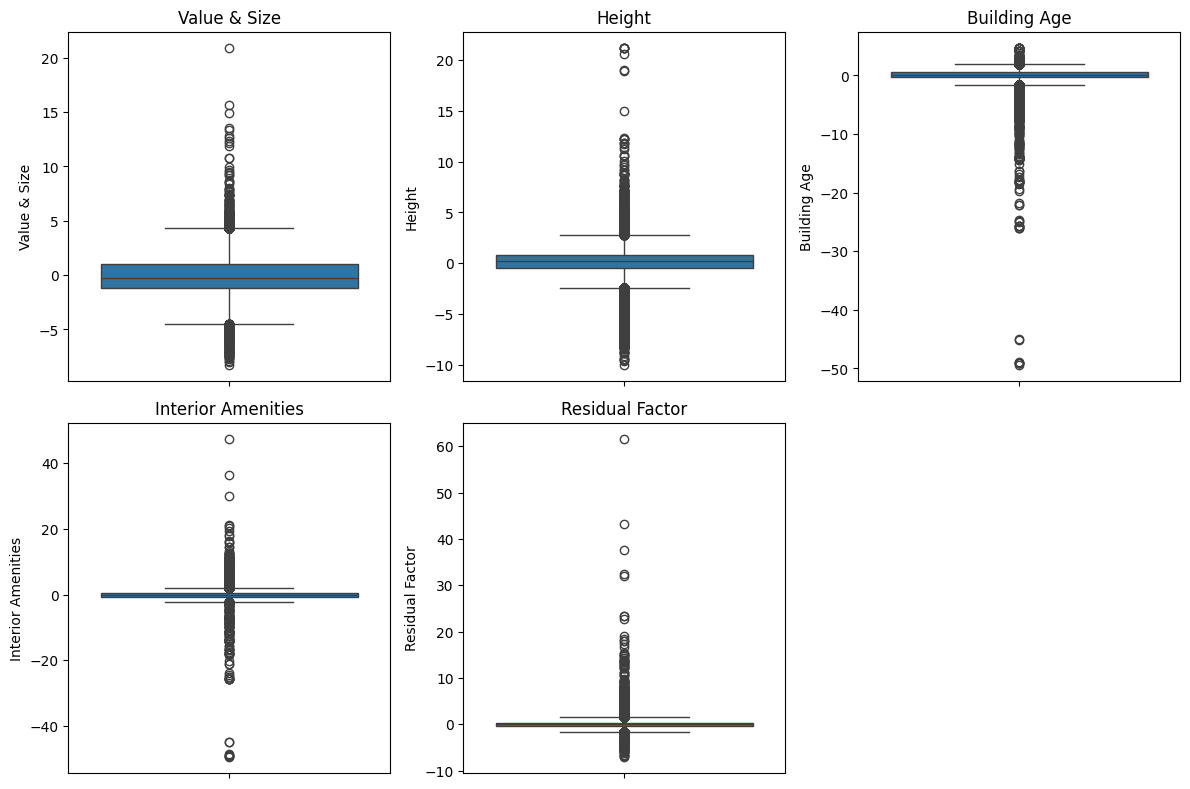

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = [ 'Value & Size', 'Height', 'Building Age', 'Interior Amenities', 'Residual Factor']

plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [61]:
from scipy import stats
import numpy as np

zscore_mask = np.zeros(len(df), dtype=bool)
zscore_info = {}

for col in num_cols:
    z_scores = np.abs(stats.zscore(df[col]))
    mask = z_scores > 3  
    zscore_info[col] = mask.sum()
    zscore_mask |= mask

df['is_outlier_zscore'] = zscore_mask
print("Z-Score Outliers (|z| > 3):")
print(f"Total: {df['is_outlier_zscore'].sum()} ({df['is_outlier_zscore'].mean()*100:.2f}%)")
print("\nOutliers per PC:")
for col, count in zscore_info.items():
    print(f"  {col}: {count}")

Z-Score Outliers (|z| > 3):
Total: 7675 (5.29%)

Outliers per PC:
  Value & Size: 391
  Height: 4863
  Building Age: 2247
  Interior Amenities: 1421
  Residual Factor: 1705


In [62]:
outlier_mask = np.zeros(len(df), dtype=bool)
outlier_info = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (df[col] < lower) | (df[col] > upper)
    outlier_info[col] = mask.sum()  
    outlier_mask |= mask

df['is_outlier_iqr'] = outlier_mask
print("IQR Outliers (1.5 * IQR rule):")
print(f"Total: {df['is_outlier_iqr'].sum()} ({df['is_outlier_iqr'].mean()*100:.2f}%)")
print("\nOutliers per PC:")
for col, count in outlier_info.items():
    print(f"  {col}: {count}")

IQR Outliers (1.5 * IQR rule):
Total: 19313 (13.32%)

Outliers per PC:
  Value & Size: 2700
  Height: 9082
  Building Age: 9081
  Interior Amenities: 4736
  Residual Factor: 6898


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144961 entries, 0 to 144960
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Country             144961 non-null  object 
 1   Property Type       144961 non-null  object 
 2   Value & Size        144961 non-null  float64
 3   Height              144961 non-null  float64
 4   Building Age        144961 non-null  float64
 5   Interior Amenities  144961 non-null  float64
 6   Residual Factor     144961 non-null  float64
 7   is_outlier_zscore   144961 non-null  bool   
 8   is_outlier_iqr      144961 non-null  bool   
dtypes: bool(2), float64(5), object(2)
memory usage: 8.0+ MB
